In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

PROJECT_ROOT = Path(r"C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x")

print("Project root:", PROJECT_ROOT)
print("Exists:", PROJECT_ROOT.exists())

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Figure directory:", FIGURE_DIR)

Libraries imported successfully
Project root: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x
Exists: True
Figure directory: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures


In [2]:
MODEL_PATH = PROJECT_ROOT / "models" / "tuned_xgboost_final.joblib"
FEATURES_PATH = PROJECT_ROOT / "models" / "final_features.joblib"
THRESHOLD_PATH = PROJECT_ROOT / "models" / "classification_threshold.joblib"

loaded_model = joblib.load(MODEL_PATH)
loaded_features = joblib.load(FEATURES_PATH)
loaded_threshold = joblib.load(THRESHOLD_PATH)

print("Model loaded successfully.")
print("Number of model features:", len(loaded_features))
print("Features:")
print(loaded_features)
print("Classification threshold:", loaded_threshold)

Model loaded successfully.
Number of model features: 15
Features:
['Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Web_Forwards']
Classification threshold: 0.47999999999999976


In [3]:
sys.path.append(str(PROJECT_ROOT))

from src.explainability.shap_utils import (
    create_explainer,
    calculate_shap_values
)

print("SHAP utilities imported successfully.")

SHAP utilities imported successfully.


In [4]:
explainer = create_explainer(loaded_model)

print("SHAP explainer created successfully.")
print("Explainer type:", type(explainer).__name__)

SHAP explainer created successfully.
Explainer type: TreeExplainer


In [6]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "phishguard_features_final_11500.csv"

df_shap = pd.read_csv(DATA_PATH)

X_shap = df_shap[loaded_features].copy()
y_shap = df_shap["Label"].copy()

print("SHAP dataset prepared successfully.")
print("Dataset shape:", df_shap.shape)
print("X_shap shape:", X_shap.shape)
print("y_shap shape:", y_shap.shape)
print("Missing values:", X_shap.isna().sum().sum())

SHAP dataset prepared successfully.
Dataset shape: (11500, 18)
X_shap shape: (11500, 15)
y_shap shape: (11500,)
Missing values: 0


In [7]:
shap_values = calculate_shap_values(
    explainer,
    X_shap
)

print("SHAP values calculated successfully.")
print("SHAP values shape:", np.asarray(shap_values).shape)

SHAP values calculated successfully.
SHAP values shape: (11500, 15)


C:\Users\nk134\AppData\Local\Temp\ipykernel_16972\556577751.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


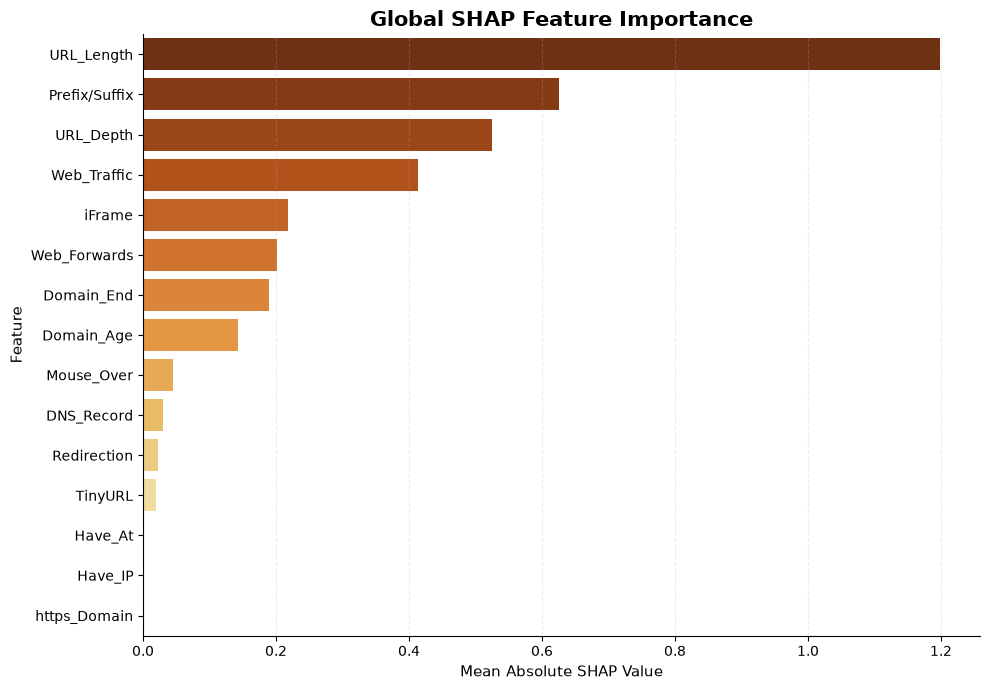

SHAP feature importance graph saved successfully.
Saved to: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\shap_feature_importance.png

Feature importance:
          Feature  Mean_Absolute_SHAP
2      URL_Length            1.198757
7   Prefix/Suffix            0.625457
3       URL_Depth            0.524690
9     Web_Traffic            0.412878
12         iFrame            0.218071
14   Web_Forwards            0.202027
11     Domain_End            0.189114
10     Domain_Age            0.142504
13     Mouse_Over            0.045491
8      DNS_Record            0.030413
4     Redirection            0.022737
6         TinyURL            0.019236
1         Have_At            0.001103
0         Have_IP            0.000239
5    https_Domain            0.000000


In [9]:
# Cell 6: Global SHAP Feature Importance

# SHAP Explanation object se actual SHAP values extract karo
shap_array = shap_values.values

# Mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_array).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": loaded_features,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

# Professional subtle warm palette
warm_palette = sns.color_palette(
    "YlOrBr",
    n_colors=len(feature_importance)
)[::-1]

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Mean_Absolute_SHAP",
    y="Feature",
    palette=warm_palette
)

plt.title(
    "Global SHAP Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Mean Absolute SHAP Value",
    fontsize=11
)

plt.ylabel(
    "Feature",
    fontsize=11
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()

output_path = FIGURE_DIR / "shap_feature_importance.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP feature importance graph saved successfully.")
print("Saved to:", output_path)

print("\nFeature importance:")
print(feature_importance)

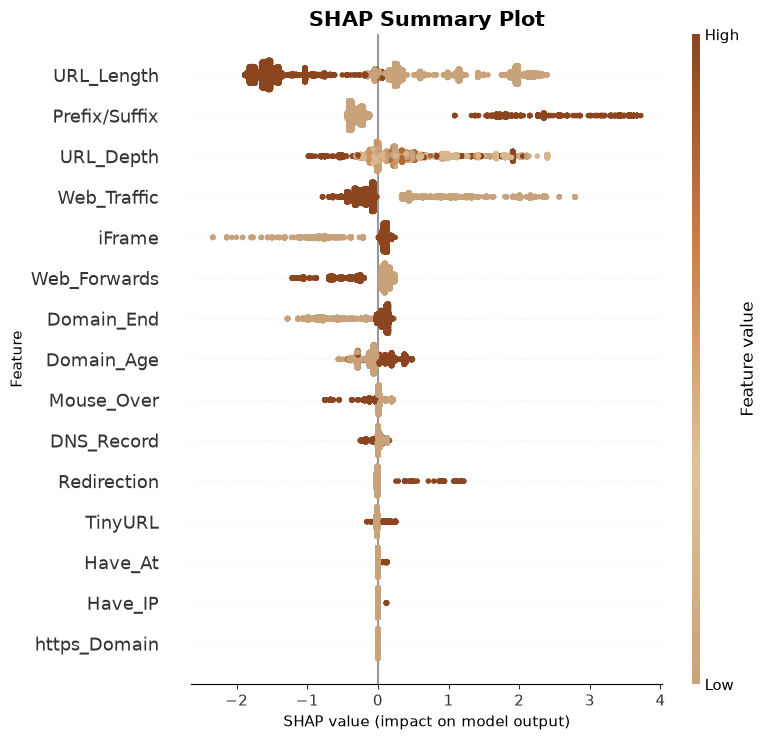

Warm SHAP summary beeswarm graph saved successfully.
Saved to: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\shap_summary_beeswarm.png


In [11]:
# Cell 7: SHAP Summary / Beeswarm Plot
# Professional subtle warm color palette

from matplotlib.colors import LinearSegmentedColormap

warm_cmap = LinearSegmentedColormap.from_list(
    "warm_shap",
    [
        "#C8A27A",   # muted warm beige
        "#E0C39B",   # soft sand
        "#C9824B",   # muted terracotta
        "#8B451F"    # warm dark brown
    ]
)

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=loaded_features,
    cmap=warm_cmap,
    show=False
)

plt.title(
    "SHAP Summary Plot",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "SHAP value (impact on model output)",
    fontsize=11
)

plt.ylabel(
    "Feature",
    fontsize=11
)

plt.tight_layout()

output_path = FIGURE_DIR / "shap_summary_beeswarm.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Warm SHAP summary beeswarm graph saved successfully.")
print("Saved to:", output_path)

<Figure size 1000x700 with 0 Axes>

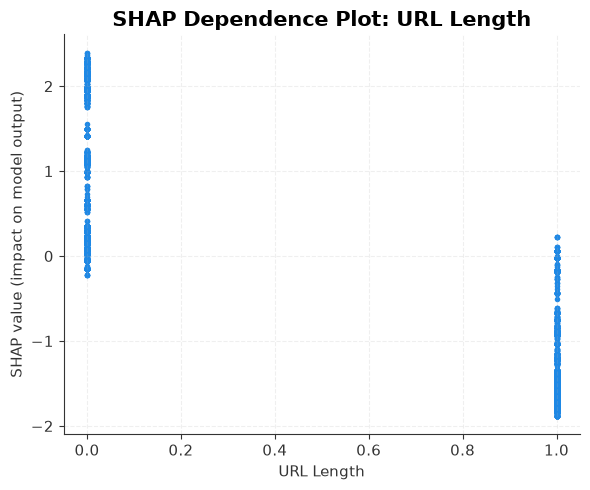

SHAP dependence plot saved successfully.
Saved to: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\shap_dependence_url_length.png


In [12]:
# Cell 8: SHAP Dependence Plot for URL_Length

from matplotlib.colors import LinearSegmentedColormap

warm_cmap = LinearSegmentedColormap.from_list(
    "warm_shap",
    [
        "#D8C0A8",
        "#C9824B",
        "#8B451F"
    ]
)

plt.figure(figsize=(10, 7))

shap.dependence_plot(
    "URL_Length",
    shap_values.values,
    X_shap,
    feature_names=loaded_features,
    interaction_index=None,
    cmap=warm_cmap,
    show=False
)

plt.title(
    "SHAP Dependence Plot: URL Length",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "URL Length",
    fontsize=11
)

plt.ylabel(
    "SHAP value (impact on model output)",
    fontsize=11
)

plt.grid(
    linestyle="--",
    alpha=0.20
)

sns.despine()

plt.tight_layout()

output_path = FIGURE_DIR / "shap_dependence_url_length.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP dependence plot saved successfully.")
print("Saved to:", output_path)

Explaining URL/domain:
metro.co.uk


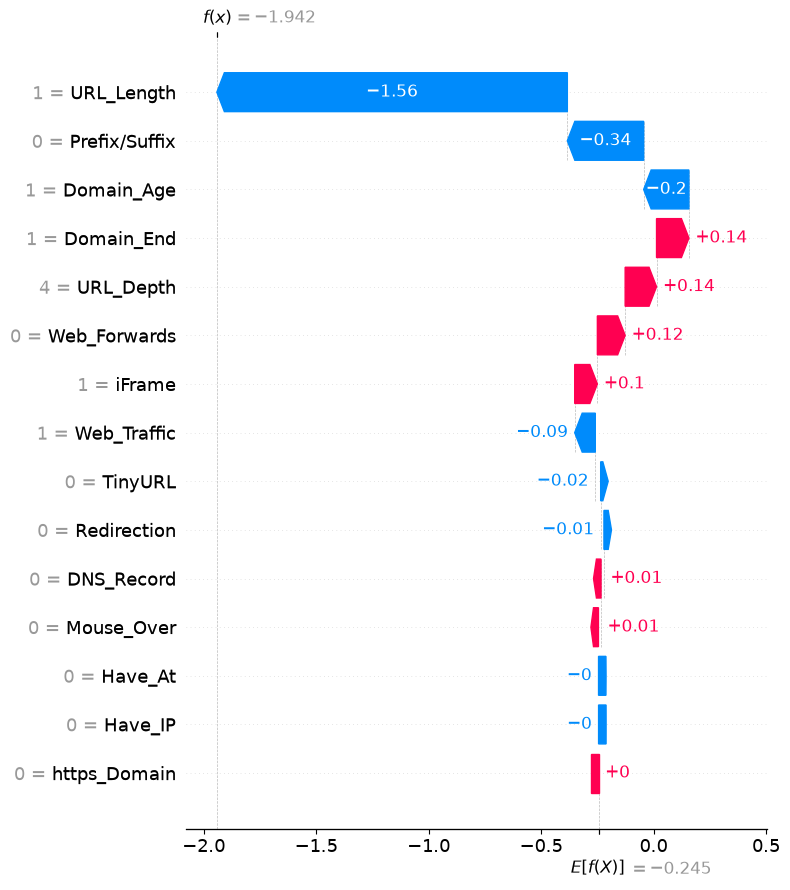


Individual URL SHAP waterfall saved successfully.
Saved to: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\shap_individual_url_waterfall.png


In [13]:
# Cell 9: Individual URL SHAP Waterfall

sample_index = 0

sample_domain = df_shap.iloc[sample_index]["Domain"]

print("Explaining URL/domain:")
print(sample_domain)

# SHAP waterfall plot
plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    shap_values[sample_index],
    max_display=15,
    show=False
)

plt.tight_layout()

output_path = FIGURE_DIR / "shap_individual_url_waterfall.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nIndividual URL SHAP waterfall saved successfully.")
print("Saved to:", output_path)

In [14]:
# Cell 10: Identify and Prepare False Positive URLs

FALSE_POSITIVE_DOMAINS = [
    "cloud.microsoft",
    "workers.dev",
    "cloudflare-dns.com"
]

fp_indices = []

for domain in FALSE_POSITIVE_DOMAINS:
    matches = df_shap.index[
        df_shap["Domain"].astype(str).str.lower() == domain.lower()
    ].tolist()

    if matches:
        fp_indices.append(matches[0])
    else:
        print(f"WARNING: {domain} not found in SHAP dataset.")

print("False-positive indices:", fp_indices)

print("\nFalse-positive URLs/domains and model probabilities:")

for idx in fp_indices:
    probability = loaded_model.predict_proba(
        X_shap.iloc[[idx]]
    )[0, 1]

    prediction = (
        "PHISHING"
        if probability >= loaded_threshold
        else "LEGITIMATE"
    )

    print(
        f"{df_shap.iloc[idx]['Domain']} "
        f"| Probability: {probability:.4f} "
        f"| Prediction: {prediction}"
    )

False-positive indices: [10541, 10568, 10564]

False-positive URLs/domains and model probabilities:
cloud.microsoft | Probability: 0.6488 | Prediction: PHISHING
workers.dev | Probability: 0.6488 | Prediction: PHISHING
cloudflare-dns.com | Probability: 0.9035 | Prediction: PHISHING


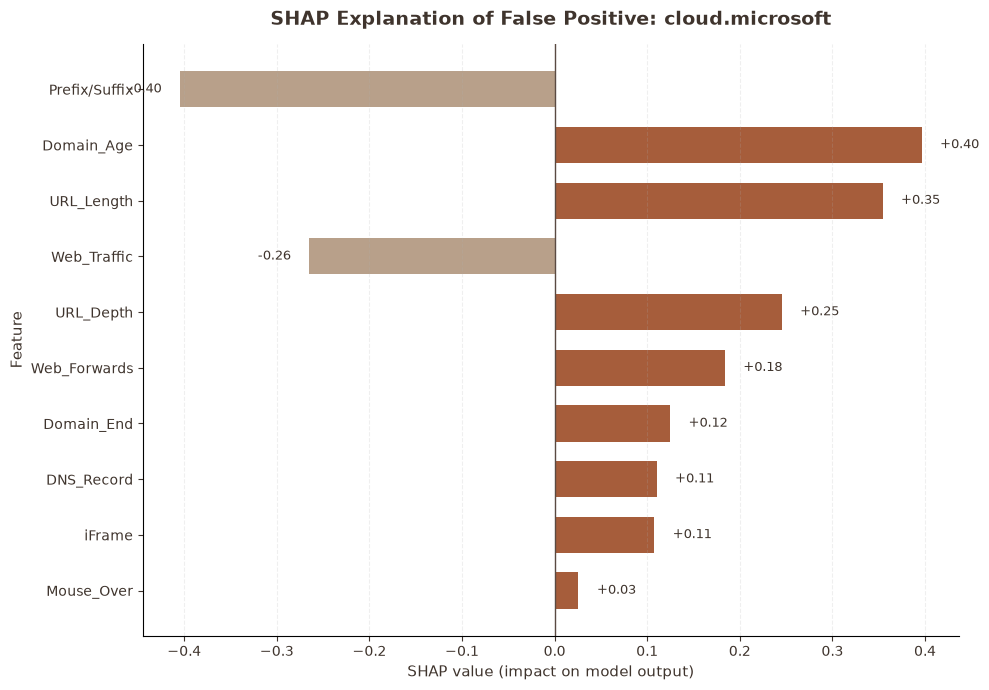

Saved: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\shap_false_positive_cloud_microsoft.png


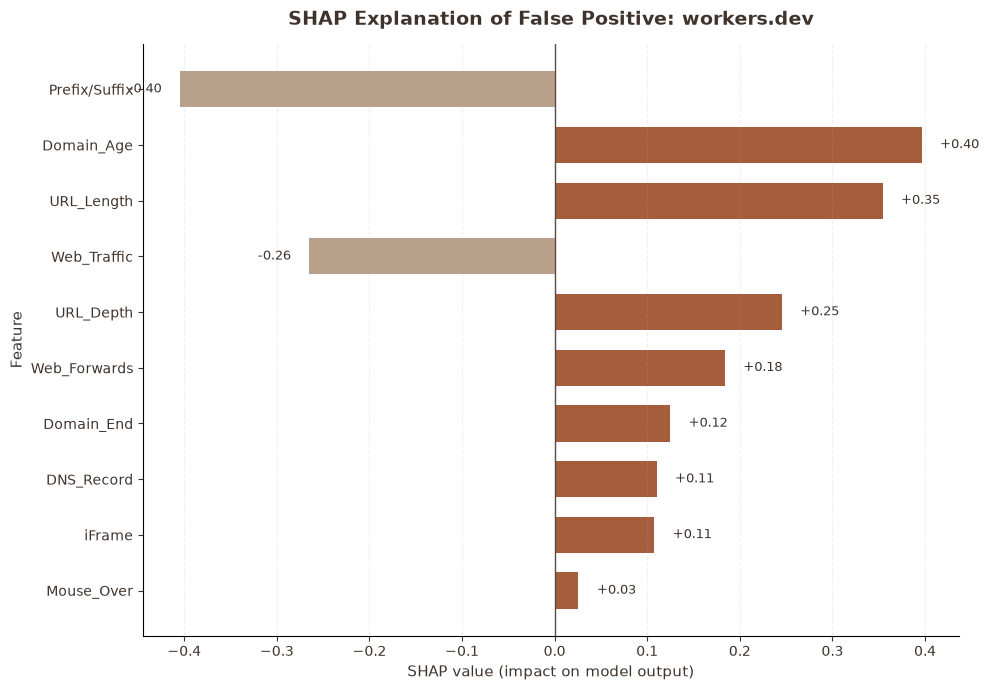

Saved: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\shap_false_positive_workers_dev.png


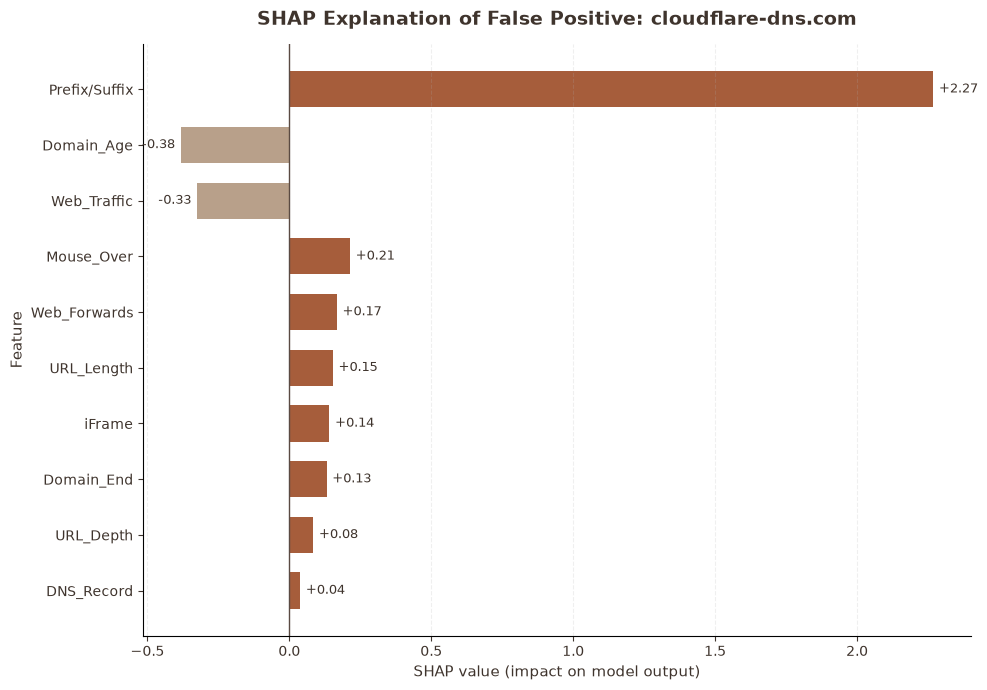

Saved: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\shap_false_positive_cloudflare_dns_com.png


In [15]:
# Cell 11: False-Positive SHAP Waterfall Analysis

import matplotlib.pyplot as plt
import numpy as np

# Professional warm colors
POSITIVE_COLOR = "#A65D3B"   # muted terracotta
NEGATIVE_COLOR = "#B8A08A"   # warm beige
TEXT_COLOR = "#3F342D"

for idx in fp_indices:

    domain = str(df_shap.iloc[idx]["Domain"])

    # SHAP values for this URL
    sample_shap = shap_values[idx].values

    # Select top 10 features by absolute SHAP contribution
    top_indices = np.argsort(
        np.abs(sample_shap)
    )[-10:][::-1]

    features = np.array(loaded_features)[top_indices]
    contributions = sample_shap[top_indices]

    # Reverse for horizontal waterfall-style display
    features = features[::-1]
    contributions = contributions[::-1]

    plt.figure(figsize=(10, 7))

    colors = [
        POSITIVE_COLOR if value > 0 else NEGATIVE_COLOR
        for value in contributions
    ]

    y_positions = np.arange(len(features))

    plt.barh(
        y_positions,
        contributions,
        color=colors,
        edgecolor="none",
        height=0.65
    )

    plt.axvline(
        0,
        color="#5A4A42",
        linewidth=1.0
    )

    plt.yticks(
        y_positions,
        features,
        fontsize=10
    )

    plt.xlabel(
        "SHAP value (impact on model output)",
        fontsize=11,
        color=TEXT_COLOR
    )

    plt.ylabel(
        "Feature",
        fontsize=11,
        color=TEXT_COLOR
    )

    plt.title(
        f"SHAP Explanation of False Positive: {domain}",
        fontsize=14,
        fontweight="bold",
        color=TEXT_COLOR,
        pad=14
    )

    plt.grid(
        axis="x",
        linestyle="--",
        alpha=0.20
    )

    plt.tick_params(
        colors=TEXT_COLOR
    )

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    # Add contribution values
    for y, value in zip(y_positions, contributions):

        offset = 0.02 if value >= 0 else -0.02

        plt.text(
            value + offset,
            y,
            f"{value:+.2f}",
            va="center",
            ha="left" if value >= 0 else "right",
            fontsize=9,
            color=TEXT_COLOR
        )

    plt.tight_layout()

    safe_domain = domain.replace(".", "_").replace("-", "_")

    output_path = (
        FIGURE_DIR /
        f"shap_false_positive_{safe_domain}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: {output_path}"
    )

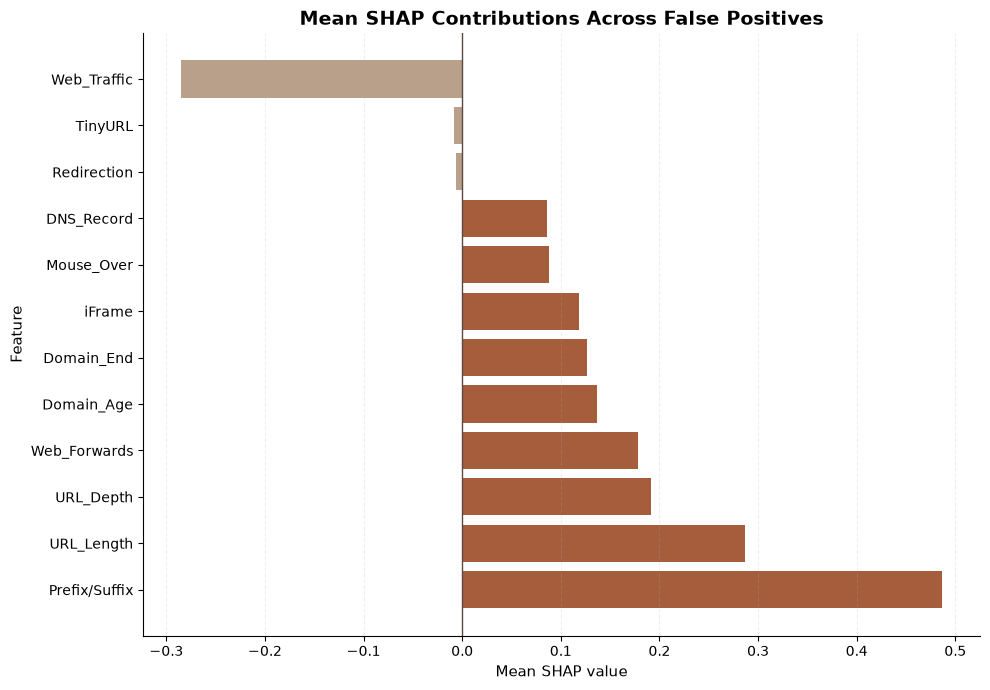

Combined false-positive SHAP analysis saved successfully.
Saved to: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\shap_false_positive_combined_analysis.png

Mean SHAP contribution across false positives:
          Feature  Mean_SHAP
7   Prefix/Suffix   0.486456
2      URL_Length   0.287112
3       URL_Depth   0.191509
14   Web_Forwards   0.178281
10     Domain_Age   0.136487
11     Domain_End   0.126762
12         iFrame   0.118714
13     Mouse_Over   0.088364
8      DNS_Record   0.086077
5    https_Domain   0.000000
0         Have_IP  -0.000052
1         Have_At  -0.000224
4     Redirection  -0.006645
6         TinyURL  -0.008277
9     Web_Traffic  -0.285062


In [16]:
# Cell 12: Combined SHAP Analysis of False Positives

fp_shap_values = shap_values.values[fp_indices]

mean_fp_shap = fp_shap_values.mean(axis=0)

fp_importance = pd.DataFrame({
    "Feature": loaded_features,
    "Mean_SHAP": mean_fp_shap
}).sort_values(
    "Mean_SHAP",
    ascending=False
)

# Keep features with non-zero average contribution
fp_plot = fp_importance[
    fp_importance["Mean_SHAP"].abs() > 0.001
].copy()

plt.figure(figsize=(10, 7))

colors = [
    "#A65D3B" if value > 0 else "#B8A08A"
    for value in fp_plot["Mean_SHAP"]
]

plt.barh(
    fp_plot["Feature"],
    fp_plot["Mean_SHAP"],
    color=colors,
    edgecolor="none"
)

plt.axvline(
    0,
    color="#5A4A42",
    linewidth=1
)

plt.xlabel(
    "Mean SHAP value",
    fontsize=11
)

plt.ylabel(
    "Feature",
    fontsize=11
)

plt.title(
    "Mean SHAP Contributions Across False Positives",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.20
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

output_path = (
    FIGURE_DIR /
    "shap_false_positive_combined_analysis.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Combined false-positive SHAP analysis saved successfully.")
print("Saved to:", output_path)

print("\nMean SHAP contribution across false positives:")
print(fp_importance)

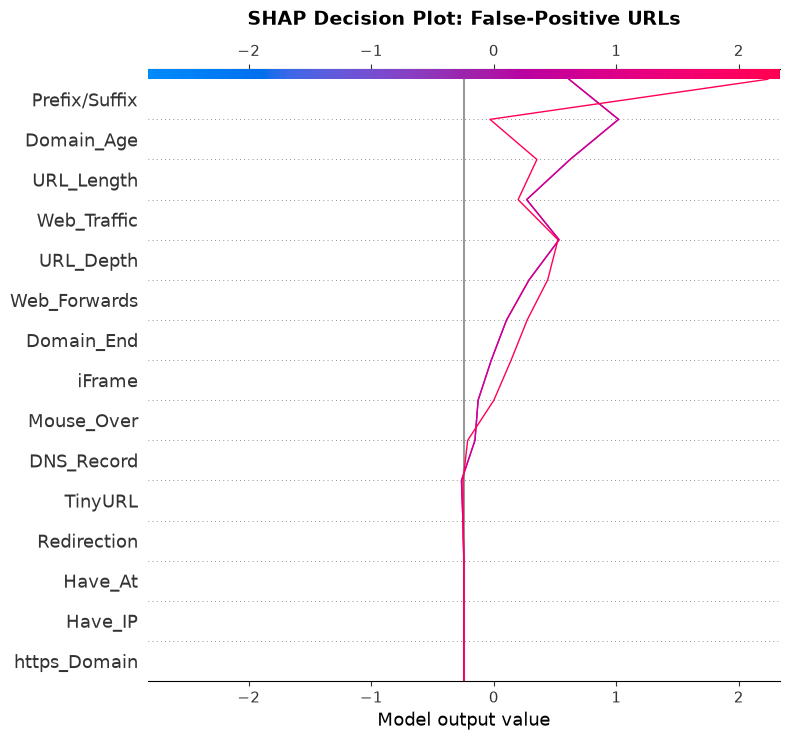

SHAP false-positive decision plot saved successfully.
Saved to: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\shap_false_positive_decision_plot.png


In [17]:
# Cell 13: SHAP Decision Plot for False Positives

fp_shap = shap_values[fp_indices]

plt.figure(figsize=(11, 8))

shap.decision_plot(
    base_value=fp_shap.base_values[0],
    shap_values=fp_shap.values,
    features=X_shap.iloc[fp_indices],
    feature_names=loaded_features,
    show=False
)

plt.title(
    "SHAP Decision Plot: False-Positive URLs",
    fontsize=14,
    fontweight="bold",
    pad=14
)

plt.tight_layout()

output_path = (
    FIGURE_DIR /
    "shap_false_positive_decision_plot.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP false-positive decision plot saved successfully.")
print("Saved to:", output_path)

In [18]:
# Cell 14: False-Positive SHAP Summary Table

fp_summary_rows = []

for idx in fp_indices:

    domain = str(df_shap.iloc[idx]["Domain"])
    sample_shap = shap_values[idx].values

    # Top 5 features by absolute SHAP contribution
    top_indices = np.argsort(
        np.abs(sample_shap)
    )[-5:][::-1]

    row = {
        "Domain": domain,
        "Model_Probability": loaded_model.predict_proba(
            X_shap.iloc[[idx]]
        )[0, 1],
        "Prediction": "PHISHING"
    }

    for rank, feature_idx in enumerate(top_indices, start=1):

        feature = loaded_features[feature_idx]
        contribution = sample_shap[feature_idx]

        row[f"Top_{rank}_Feature"] = feature
        row[f"Top_{rank}_SHAP"] = contribution

    fp_summary_rows.append(row)

fp_summary_df = pd.DataFrame(fp_summary_rows)

print("False-positive SHAP summary table created successfully.")
print()

display(fp_summary_df)

False-positive SHAP summary table created successfully.



,Domain,Model_Probability,Prediction,Top_1_Feature,Top_1_SHAP,Top_2_Feature,Top_2_SHAP,Top_3_Feature,Top_3_SHAP,Top_4_Feature,Top_4_SHAP,Top_5_Feature,Top_5_SHAP
0,cloud.microsoft,0.648834,PHISHING,Prefix/Suffix,-0.40447,Domain_Age,0.396243,URL_Length,0.354069,Web_Traffic,-0.264834,URL_Depth,0.245144
1,workers.dev,0.648834,PHISHING,Prefix/Suffix,-0.40447,Domain_Age,0.396243,URL_Length,0.354069,Web_Traffic,-0.264834,URL_Depth,0.245144
2,cloudflare-dns.com,0.903519,PHISHING,Prefix/Suffix,2.26831,Domain_Age,-0.383026,Web_Traffic,-0.325517,Mouse_Over,0.213616,Web_Forwards,0.167336


In [19]:
# Cell 15: Save False-Positive SHAP Summary

output_csv = (
    PROJECT_ROOT
    / "data"
    / "validation"
    / "false_positive_shap_summary.csv"
)

fp_summary_df.to_csv(
    output_csv,
    index=False
)

print("False-positive SHAP summary saved successfully.")
print("Saved to:", output_csv)
print("Rows:", len(fp_summary_df))
print("Columns:", len(fp_summary_df.columns))

False-positive SHAP summary saved successfully.
Saved to: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\data\validation\false_positive_shap_summary.csv
Rows: 3
Columns: 13


In [20]:
# Cell 16: Save SHAP Explainer

SHAP_EXPLAINER_PATH = (
    PROJECT_ROOT
    / "models"
    / "shap_explainer.joblib"
)

joblib.dump(
    explainer,
    SHAP_EXPLAINER_PATH
)

print("SHAP explainer saved successfully.")
print("Saved to:", SHAP_EXPLAINER_PATH)

SHAP explainer saved successfully.
Saved to: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\models\shap_explainer.joblib


In [21]:
# Cell 17: Verify Saved SHAP Explainer

saved_explainer = joblib.load(
    SHAP_EXPLAINER_PATH
)

print("Saved SHAP explainer loaded successfully.")
print("Explainer type:", type(saved_explainer).__name__)

# Verify it can calculate SHAP values
test_shap = saved_explainer(
    X_shap.iloc[:5]
)

print("SHAP verification successful.")
print("Verification SHAP shape:", test_shap.values.shape)

Saved SHAP explainer loaded successfully.
Explainer type: TreeExplainer
SHAP verification successful.
Verification SHAP shape: (5, 15)
